In [100]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [101]:
df = pd.read_csv("placement_readiness_synthetic_10000.csv")

In [102]:
df.head()
df.info()
df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 22 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   name            10000 non-null  object 
 1   email           10000 non-null  object 
 2   gender          10000 non-null  object 
 3   age             10000 non-null  int64  
 4   course          10000 non-null  object 
 5   other_course    1277 non-null   object 
 6   branch          10000 non-null  object 
 7   year            10000 non-null  object 
 8   cgpa            10000 non-null  float64
 9   backlogs        7319 non-null   object 
 10  projects        10000 non-null  int64  
 11  tech_skill      10000 non-null  int64  
 12  comm_skill      10000 non-null  int64  
 13  apt_skill       10000 non-null  int64  
 14  team_skill      10000 non-null  int64  
 15  languages       7459 non-null   object 
 16  certifications  7414 non-null   object 
 17  participation   10000 non-null  

name                 0
email                0
gender               0
age                  0
course               0
other_course      8723
branch               0
year                 0
cgpa                 0
backlogs          2681
projects             0
tech_skill           0
comm_skill           0
apt_skill            0
team_skill           0
languages         2541
certifications    2586
participation        0
internship           0
training             0
placement            0
opinion              0
dtype: int64

In [103]:
missing = df.isnull().sum()
missing_percent = (missing / len(df)) * 100

pd.DataFrame({
    "Missing": missing,
    "Percentage": missing_percent
}).sort_values("Percentage", ascending=False)

,Missing,Percentage
other_course,8723,87.23
backlogs,2681,26.81
certifications,2586,25.86
languages,2541,25.41
email,0,0.00
name,0,0.00
course,0,0.00
age,0,0.00
gender,0,0.00
branch,0,0.00


In [104]:
df["other_course"] = df["other_course"].fillna("None")

In [105]:
df["backlogs"] = df["backlogs"].fillna(0)

In [106]:
df["languages"] = df["languages"].fillna("None")

In [107]:
df["certifications"] = df["certifications"].fillna("None")

In [108]:
df.isnull().sum()

name              0
email             0
gender            0
age               0
course            0
other_course      0
branch            0
year              0
cgpa              0
backlogs          0
projects          0
tech_skill        0
comm_skill        0
apt_skill         0
team_skill        0
languages         0
certifications    0
participation     0
internship        0
training          0
placement         0
opinion           0
dtype: int64

In [109]:
drop_cols = ["name", "email", "opinion"]
df = df.drop(columns=drop_cols)
X = df.drop(columns=["placement"])
y = df["placement"]
X.head()

,gender,age,course,other_course,branch,year,cgpa,backlogs,projects,tech_skill,comm_skill,apt_skill,team_skill,languages,certifications,participation,internship,training
0,Female,18,BCA,None,IT,Completed,5.55,3+,1,3,5,3,4,C,None,Yes,Yes,Yes
1,Male,25,B.Tech,None,Electrical,3rd Year,5.67,2,9,3,1,4,1,None,None,Yes,Yes,No
2,Female,20,B.Sc,None,CSE,4th Year,9.20,1,10,5,4,1,2,C,Data Analytics,No,Yes,Yes
3,Female,25,Other,Ceramics designer,CSE,2nd Year,6.71,3+,7,2,5,3,4,None,Other;Cloud Computing,Yes,Yes,Yes
4,Female,19,BCA,None,ECE,4th Year,6.40,0,3,3,1,5,1,JavaScript;Python;C,Data Analytics,Yes,No,No


In [110]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 19 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   gender          10000 non-null  object 
 1   age             10000 non-null  int64  
 2   course          10000 non-null  object 
 3   other_course    10000 non-null  object 
 4   branch          10000 non-null  object 
 5   year            10000 non-null  object 
 6   cgpa            10000 non-null  float64
 7   backlogs        10000 non-null  object 
 8   projects        10000 non-null  int64  
 9   tech_skill      10000 non-null  int64  
 10  comm_skill      10000 non-null  int64  
 11  apt_skill       10000 non-null  int64  
 12  team_skill      10000 non-null  int64  
 13  languages       10000 non-null  object 
 14  certifications  10000 non-null  object 
 15  participation   10000 non-null  object 
 16  internship      10000 non-null  object 
 17  training        10000 non-null  

In [111]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y = le.fit_transform(y)
print(y)

[1 1 1 ... 0 0 0]


In [112]:
categorical_cols = [
    "gender",
    "course",
    "other_course",
    "branch",
    "year",
    "languages",
    "certifications",
    "participation",
    "internship",
    "training"
]
X = pd.get_dummies(
    X,
    columns=categorical_cols,
    drop_first=True,
    dtype=int
)

In [113]:
def convert_backlogs(x):
    if isinstance(x, str) and x.endswith("+"):
        return int(x[:-1])
    return int(x)

X["backlogs"] = X["backlogs"].apply(convert_backlogs)

In [114]:
X.head()

,age,cgpa,backlogs,projects,tech_skill,comm_skill,apt_skill,team_skill,gender_Male,gender_Other,...,certifications_Other;Cyber Security,certifications_Other;Cyber Security;AI/ML,certifications_Other;Cyber Security;Cloud Computing,certifications_Other;Cyber Security;Data Analytics,certifications_Other;Data Analytics,certifications_Other;Data Analytics;Cloud Computing,certifications_Other;Data Analytics;Cyber Security,participation_Yes,internship_Yes,training_Yes
0,18,5.55,3,1,3,5,3,4,0,0,...,0,0,0,0,0,0,0,1,1,1
1,25,5.67,2,9,3,1,4,1,1,0,...,0,0,0,0,0,0,0,1,1,0
2,20,9.20,1,10,5,4,1,2,0,0,...,0,0,0,0,0,0,0,0,1,1
3,25,6.71,3,7,2,5,3,4,0,0,...,0,0,0,0,0,0,0,1,1,1
4,19,6.40,0,3,3,1,5,1,0,0,...,0,0,0,0,0,0,0,1,0,0


<Axes: >

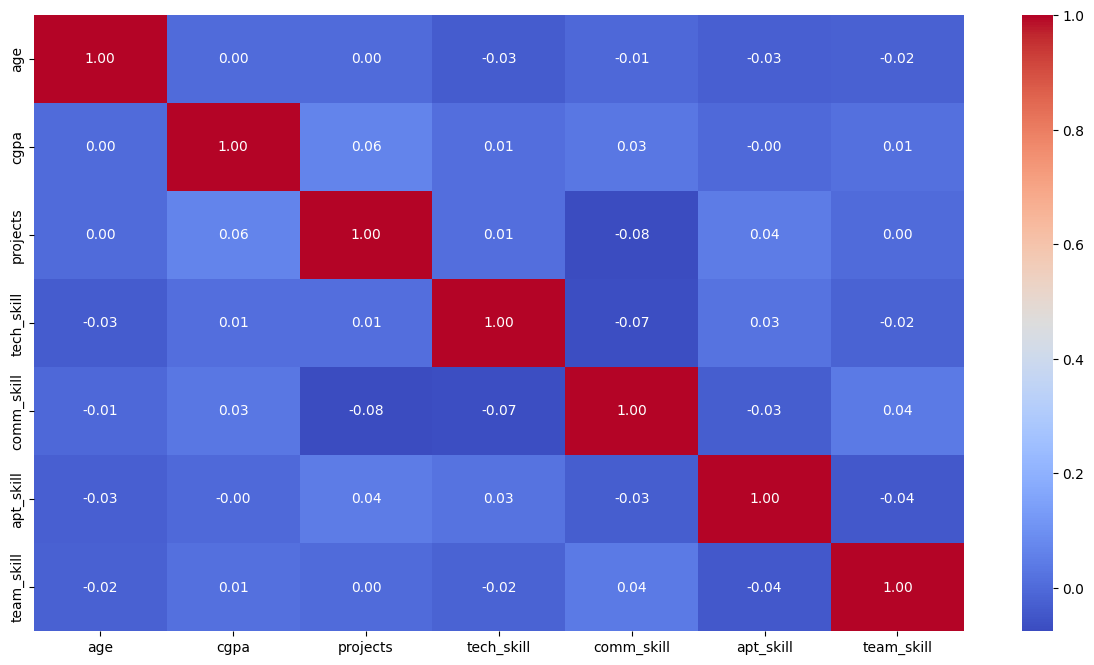

In [115]:
num_cols = df.select_dtypes(include="number")
corr_matrix = num_cols.corr()
plt.figure(figsize=(15, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)


In [116]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [117]:
X_test.head()

,age,cgpa,backlogs,projects,tech_skill,comm_skill,apt_skill,team_skill,gender_Male,gender_Other,...,certifications_Other;Cyber Security,certifications_Other;Cyber Security;AI/ML,certifications_Other;Cyber Security;Cloud Computing,certifications_Other;Cyber Security;Data Analytics,certifications_Other;Data Analytics,certifications_Other;Data Analytics;Cloud Computing,certifications_Other;Data Analytics;Cyber Security,participation_Yes,internship_Yes,training_Yes
6252,23,9.70,2,5,1,1,4,3,0,1,...,0,0,0,0,0,0,0,0,1,1
4684,23,9.54,1,0,4,5,3,5,0,1,...,0,0,0,0,0,0,0,0,1,0
1731,26,8.85,0,2,2,5,5,3,0,1,...,0,0,0,0,0,0,0,0,0,0
4742,26,6.49,3,1,3,5,4,5,0,0,...,0,0,0,0,0,0,0,1,0,1
4521,18,7.67,3,5,2,3,2,1,0,1,...,0,0,0,0,0,1,0,1,0,0


In [118]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [119]:
# Logistic regression

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

log_model = LogisticRegression()
log_model.fit(X_train_scaled, y_train)

y_pred = log_model.predict(X_test_scaled)

# Evaluation
print("Logistic Regression Model")
print("Precision: ", precision_score(y_test, y_pred))
print("Recall: ", recall_score(y_test, y_pred))
print("F1 score: ", f1_score(y_test, y_pred))
print("Accuracy: ", accuracy_score(y_test, y_pred))
print("CM: ", confusion_matrix(y_test, y_pred))

Logistic Regression Model
Precision:  0.677277716794731
Recall:  0.667027027027027
F1 score:  0.6721132897603486
Accuracy:  0.699
CM:  [[781 294]
 [308 617]]


In [120]:
# KNN

from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=3)
knn_model.fit(X_train_scaled, y_train)

y_pred = knn_model.predict(X_test_scaled)

# Evaluation
print("KNN Model")
print("Precision: ", precision_score(y_test, y_pred))
print("Recall: ", recall_score(y_test, y_pred))
print("F1 score: ", f1_score(y_test, y_pred))
print("Accuracy: ", accuracy_score(y_test, y_pred))
print("CM: ", confusion_matrix(y_test, y_pred))

KNN Model
Precision:  0.9978401727861771
Recall:  0.9989189189189189
F1 score:  0.9983792544570502
Accuracy:  0.9985
CM:  [[1073    2]
 [   1  924]]


In [122]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(knn_model, X, y, cv=5, scoring='accuracy')

print(scores)
print("Mean CV Accuracy:", scores.mean())

[0.9995 0.9915 0.9975 1.     0.9975]
Mean CV Accuracy: 0.9972000000000001


In [ ]:
# Naive Bayes

from sklearn.naive_bayes import GaussianNB

nb_model = GaussianNB()
nb_model.fit(X_train_scaled, y_train)

y_pred = nb_model.predict(X_test_scaled)

# Evaluation
print("Naive Bayes Model")
print("Precision: ", precision_score(y_test, y_pred))
print("Recall: ", recall_score(y_test, y_pred))
print("F1 score: ", f1_score(y_test, y_pred))
print("Accuracy: ", accuracy_score(y_test, y_pred))
print("CM: ", confusion_matrix(y_test, y_pred))

Naive Bayes Model
Precision:  0.5373044524669074
Recall:  0.9654054054054054
F1 score:  0.6903749516814843
Accuracy:  0.5995
CM:  [[306 769]
 [ 32 893]]


In [ ]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=3,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Random Forest precision:", precision_score(y_test, y_pred_rf))
print("F1 score: ", f1_score(y_test, y_pred))
print("Random Forest Recall:", recall_score(y_test, y_pred_rf))
print("CM: ", confusion_matrix(y_test, y_pred))


Random Forest Accuracy: 0.5605
Random Forest precision: 1.0
F1 score:  0.6903749516814843
Random Forest Recall: 0.04972972972972973
CM:  [[306 769]
 [ 32 893]]


In [ ]:
from xgboost import XGBClassifier

xg = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    random_state=42
)

xg.fit(X_train, y_train)

y_pred_rf = xg.predict(X_test)

print("xg boost Accuracy:", accuracy_score(y_test, y_pred_rf))
print("xg boost precision:", precision_score(y_test, y_pred_rf))
print("F1 score: ", f1_score(y_test, y_pred))
print("xg boost Recall:", recall_score(y_test, y_pred_rf))
print("CM: ", confusion_matrix(y_test, y_pred))


xg boost Accuracy: 0.898
xg boost precision: 0.9186991869918699
F1 score:  0.6903749516814843
xg boost Recall: 0.8551351351351352
CM:  [[306 769]
 [ 32 893]]
